# Old

In [ ]:
# import random
# import pandas as pd

# from pathlib import Path

In [ ]:
# # climb up until we reach the repo root
# my_path = Path.cwd()
# print("Starting from:", my_path)
# while my_path.name != "Backbone-Graph":
#     my_path = my_path.parent
# results_dir_path = my_path / "final_results"


# top_posts_file_paths = sorted(
#     results_dir_path.rglob("topics_top_posts.parquet")
# )

# print("Found:", len(top_posts_file_paths))
# print(*top_posts_file_paths, sep="\n")


In [ ]:
# path_number  = 0 # Change this index to load different directories

# top_post_df = pd.read_parquet(top_posts_file_paths[path_number])


# display(top_post_df.head())

In [ ]:
# # The index are topics
# topic = random.randint(0, len(top_post_df)-1)
# top_post_lst = top_post_df.iloc[topic].to_list()
# print(f"Top posts for topic {topic}:")
# for i, post in enumerate(top_post_lst, 1):
#     print(f"{i}. {post}")

# Topic Clustering Evaluation

## Parametes

In [ ]:
min_topic_size_lst = 512
text_col = "translated_post"

number_of_topics = 5
number_of_posts = 10

In [ ]:
topic_col = f"BERTopic_topic_{min_topic_size_lst}"
prob_col = f"BERTopic_prob{min_topic_size_lst}"

## Utils

In [1]:
import pandas as pd
import pyarrow
import numpy as np

## Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_path = "/home/amitner/Backbone-Graph/results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet"

df_path = '/content/drive/Shareddrives/KeyBoostAuthor/Labeled_Dataset_with_Topic_NER/processed_Ecuador_part_all.gzip.parquet'
df = pd.read_parquet(df_path)

In [4]:
print("df shape:", df.shape)
print("df columns:", df.columns)

df shape: (1468565, 29)
df columns: Index(['postid', 'post_text', 'application_name', 'post_language',
       'in_reply_to_postid', 'in_reply_to_accountid', 'post_time', 'accountid',
       'account_profile_description', 'follower_count', 'following_count',
       'account_creation_date', 'is_repost', 'reposted_accountid',
       'reposted_postid', 'hashtags', 'urls', 'account_mentions', 'is_control',
       'clean_text_with_entities', 'clean_text_without_enteties',
       'translated_post', 'BERTopic_topic_512', 'BERTopic_prob512',
       'BERTopic_topic_256', 'BERTopic_prob256', 'BERTopic_topic_128',
       'BERTopic_prob128', 'ner_entities'],
      dtype='object')


In [10]:
df[['postid','post_text','post_time','translated_post','BERTopic_topic_512', 'BERTopic_prob512',
       'BERTopic_topic_256', 'BERTopic_prob256', 'BERTopic_topic_128',
       'BERTopic_prob128']]

,postid,post_text,post_time,translated_post,BERTopic_topic_512,BERTopic_prob512,BERTopic_topic_256,BERTopic_prob256,BERTopic_topic_128,BERTopic_prob128
0,0bafe020a260495bee38b98fde83668d924454019b,Vamos a cambiar la forma de hacer comunicación corporativa,2010-03-13 02:52:00,going change way corporate communication done.,-1,0.722297,0,0.672197,4,0.694254
1,608fba51f2460c7f1ca527dfc48de2bc858d4ad201,"Damos servicio de manejo de prensa, elaboración estrategias de comunicación, manejo de crisis, media training, think tank, lobbyng...",2010-03-13 03:08:00,"provide media management services, communication strategies, crisis management, media training, tank, lobbying...",-1,0.651021,0,0.622568,82,0.756225
2,514b2c38b26e240cac85382be74ed7d61a02468ac1,"@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bueno se estan destapando mascaras, ya pueden a ser una nueva Pelicula ""La Mascara Reloader""",2010-03-13 15:26:00,"well, masks unveiled, new movie ""the reloader mask""",0,0.596310,0,0.605958,18,0.694943
3,e82a816068e88387d19430348f0420b040e0d11b4e,"Mario, debemos denuciar que en los poderes publicos, hay mucho chavista disfrazado maltratando al publico y eso es negativo para el pueblo.",2010-03-13 15:32:00,"mario, must denounce public authorities, lot chavista disguise abusing public negative people.",-1,0.675815,0,0.680324,2,0.801221
4,13ed6aaeec4fffaf840f1c42ff88f5ab2cb324be64,"Tambien debemos estar claro que la oposición esta invirtiendo en la delicuencia, para atacar el gobierno y que la policia nacional funcione",2010-03-13 15:35:00,"must also clear opposition investing crime, attack government national police work.",-1,0.625230,0,0.557243,0,0.673560
...,...,...,...,...,...,...,...,...,...,...
1468560,7d4943612fa49e3383aaf35e574c57100440f05c19,". @110b1dc0680903c6b445844bb2b114643eb1e6f837 en su compromiso de garantizar la educación para personas en situación de escolaridad inconclusa, cuenta con 3.192 docentes capacitados en procesos formativos de jóvenes y adultos #TodosABC. https://5150ca8fe6e51756d4420bbcee9d53da435854e249",2019-07-30 23:59:36,". <user> commitment ensuring education unfinished schooling, 3,192 teachers trained training processes young adults world. <url>",-1,0.728308,0,0.653372,15,0.826072
1468561,9c2a3050ec05d05f083438a6163ce96099e1a88e9d,"AHORA | Vicepresidente de la República, @7cb40e447bc7687a413d1436fbbf145a23dbbe3c54, ministra de Educación, @a348071bbdded88a94ec657f3e0b7790c12e2a0698, ministra del @a56426459c348e6fb4a8411743259b2b283e69e165, @e40e962a593739b49a2e8e3872926d6130763d509c y autoridades de Estado participan en la Graduación de estudiantes de Bachillerato de la Campaña #TodosABC, 2017-2019, en Quito. https://b43da03566a2af1bce7f3b0d19662e400e990d3b3e",2019-07-30 23:59:45,"vice president republic, user, minister education, user, minister user, user state authorities participating graduation allabc's 2017-2019 campaign bachelor students.",-1,0.719401,0,0.603348,15,0.753167
1468562,c3e606bde49d62fd51fbcf381b647f7713af4675dd,"La Campaña #TodosABC cuenta con un diseño curricular y material educativo específico para jóvenes y adultos, adaptado a sus necesidades y realidades. https://c7964c9109331e1466df59167ca6328d9179eb4558",2019-07-30 23:59:48,"allabc campaign specific curriculum design educational material young adults, tailored realities.",-1,0.686315,30,0.594634,15,0.774811
1468563,a0dcb2fae5dcc88bc1a543a758e48207ec9c3ee040,"A escala nacional en el 2019, alrededor de 134 mil estudiantes continúan en las aulas gracias a la Campaña #TodosABC https://e29f685100f6f94969705abf7992942dacc01c46ae",2019-07-30 23:59:51,"nationally 2019, 134 thousand students continue classroom thanks allabc <url> campaign",-1,0.667672,0,0.605200,15,0.809461


## Report

In [12]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 9.6 MB/s eta 0:00:00


In [13]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

texts = df["translated_post"].fillna("").tolist()
tokenized_texts = [doc.split() for doc in texts]

dictionary = Dictionary(tokenized_texts)

def extract_topic_words_from_df(df, topic_col, text_col, top_n=10):

    topics_words = []

    for topic_id in df[topic_col].unique():

        if topic_id == -1:
            continue

        docs = df[df[topic_col] == topic_id][text_col].dropna().tolist()

        if len(docs) < 5:
            continue

        vectorizer = TfidfVectorizer(max_features=5000)
        X = vectorizer.fit_transform(docs)

        scores = np.asarray(X.mean(axis=0)).flatten()
        words = np.array(vectorizer.get_feature_names_out())

        top_words = words[scores.argsort()[::-1][:top_n]]

        topics_words.append(list(top_words))

    return topics_words

def compute_coherence_from_df(df, topic_col, text_col):

    topics_words = extract_topic_words_from_df(df, topic_col, text_col)

    coherence_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    return coherence_model.get_coherence()

In [16]:
coh_512 = compute_coherence_from_df(df, "BERTopic_topic_512", "translated_post")
coh_256 = compute_coherence_from_df(df, "BERTopic_topic_256", "translated_post")
coh_128 = compute_coherence_from_df(df, "BERTopic_topic_128", "translated_post")

print(coh_512, coh_256, coh_128)

0.5723438129409142 0.5204773867332979 0.4980855442342023


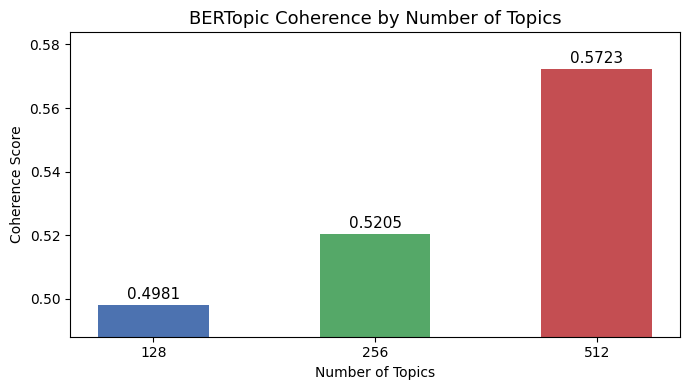

In [17]:
import matplotlib.pyplot as plt

configs = ['128', '256', '512']
scores = [coh_128, coh_256, coh_512]

plt.figure(figsize=(7, 4))
bars = plt.bar(configs, scores, color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.4f}', ha='center', va='bottom', fontsize=11)

plt.title('BERTopic Coherence by Number of Topics', fontsize=13)
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')
plt.ylim(min(scores) * 0.98, max(scores) * 1.02)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

models = [
    ('BERTopic_topic_128', 'BERTopic 128', '#4C72B0'),
    ('BERTopic_topic_256', 'BERTopic 256', '#55A868'),
    ('BERTopic_topic_512', 'BERTopic 512', '#C44E52'),
]

for ax, (col, title, color) in zip(axes, models):
    topic_counts = df[col].value_counts().sort_index()

    ax.bar(topic_counts.index.astype(str), topic_counts.values, color=color, alpha=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Topic ID')
    ax.set_ylabel('Number of Posts')

    # Rotate x labels if many topics
    n_topics = len(topic_counts)
    if n_topics > 20:
        ax.set_xticks([])
        ax.set_xlabel(f'Topic ID ({n_topics} topics)')
    else:
        ax.tick_params(axis='x', rotation=90)

    # Highlight -1 (outliers) in gray
    bars = ax.patches
    for bar, idx in zip(bars, topic_counts.index):
        if idx == -1:
            bar.set_color('gray')
            bar.set_alpha(0.6)

gray_patch = mpatches.Patch(color='gray', alpha=0.6, label='Topic -1 (outliers)')
fig.legend(handles=[gray_patch], loc='upper center', fontsize=11)

plt.suptitle('Topic Distribution per Model', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
pd.set_option("display.max_colwidth", None)

all_topics = pd.Series(df[topic_col].dropna().unique())
all_topics = all_topics[all_topics != -1]

rng = np.random.default_rng()
sampled_topics = rng.choice(all_topics.to_numpy(), size=number_of_topics, replace=False)

rows = []

for topic in sampled_topics:
    topic_df = df.loc[df[topic_col] == topic, [text_col, prob_col]]
    topic_df = topic_df.drop_duplicates(subset=[text_col])
    topic_df = topic_df.nlargest(number_of_posts, prob_col)

    row = {topic_col: topic}
    for i, text in enumerate(topic_df[text_col], start=1):
        row[f"post_{i}"] = text

    rows.append(row)

wide_df = pd.DataFrame(rows)

display(wide_df)


,BERTopic_topic_512,post_1,post_2,post_3,post_4,post_5,post_6,post_7,post_8,post_9,post_10
0,13,commission shall adopt implementing acts accordance opinion european parliament council.,commission shall adopt delegated acts accordance opinion european parliament council.,"addition this, commission shall adopt implementing acts accordance opinion european parliament council.",commission shall adopt implementing acts accordance opinion european parliament council accordance opinion european parliament council.,commission shall adopt following implementing acts accordance opinion european parliament council:,"commission shall adopt implementing acts accordance opinion european parliament council, accordance opinion european parliament council.","purposes decision, commission shall adopt implementing acts accordance opinion european parliament council.",commission shall empowered adopt delegated acts accordance opinion european parliament council.,commission shall adopt implementing acts accordance procedure referred paragraph 1 article accordance opinion european parliament council.,"commission shall adopt implementing acts accordance opinion european parliament council, accordance opinion standing committee committee regions."
1,16,4956 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4935 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4958 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4954 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4951 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4938 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4931 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4939 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4944 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico,4946 laobritotrendy dannapaola rules chauffeur kings caelitrendy arriving hard house michaelronda isabella castle kcamexico
2,15,regulation shall enter force twentieth day following publication official journal european union.,amendment 1 regulation shall enter force twentieth day following publication official journal european union.,"regulation shall enter force twentieth day following publication official journal european union, shall enter force twentieth day following publication official journal european union.",regulation shall enter force twentieth day following publication official journal european union shall enter force twenty-first day following publication official journal european union.,regulation shall enter force twentieth day following publication official journal european union shall enter force twentieth day following publication official journal european union.,decision shall enter force twentieth day following publication official journal european union.,agreement shall enter force twentieth day following publication official journal european union.,item intended enter force twentieth day following publication official journal european union.,item intended enter force day following publication official journal european union.,european commission decided extend scope regulation cover following areas:
3,20,<user> votes choicelatinartist teenchoice <user>,<user> give add votes choicelatinartist teenchoice <user>,<user> vote category choicelatinartist teenchoice <user>,<user> voting teenchoice choicelatinartist <user>,<user> <user> <user> best choicelatinartist teenchoice <user>,<user> add 

In [6]:
min_topic_size_lst = 512
text_col = "translated_post"

number_of_topics = 5
number_of_posts = 10

In [7]:
topic_col = f"BERTopic_topic_{min_topic_size_lst}"
prob_col = f"BERTopic_prob{min_topic_size_lst}"

## Coherence - Doesn't work

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

sample_docs = 50000
top_n_words = 10
coherence_type = "c_v"

work_df = df[[text_col, topic_col]].dropna()
work_df = work_df[work_df[topic_col] != -1]

if sample_docs and len(work_df) > sample_docs:
    work_df = work_df.sample(n=sample_docs, random_state=42)

# Reset index to ensure alignment between dataframe and arrays
work_df = work_df.reset_index(drop=True)

texts = work_df[text_col].astype(str).tolist()
vectorizer = CountVectorizer(stop_words="english", max_df=0.95, min_df=5)
analyzer = vectorizer.build_analyzer()
tokenized_texts = [analyzer(t) for t in texts]

dictionary = Dictionary(tokenized_texts)

X = vectorizer.fit_transform(texts)
vocab = vectorizer.get_feature_names_out()

topics = work_df[topic_col].to_numpy()
unique_topics = np.sort(np.unique(topics))

filtered_topic_ids = []
filtered_topic_words = []

for topic_id in unique_topics:
    rows = np.where(topics == topic_id)[0]
    if rows.size == 0:
        continue
    topic_counts = np.asarray(X[rows].sum(axis=0)).ravel()
    top_idx = np.argsort(topic_counts)[::-1][:top_n_words]
    top_words = [vocab[i] for i in top_idx if topic_counts[i] > 0]
    if not top_words:
        continue
    filtered_topic_ids.append(int(topic_id))
    filtered_topic_words.append(top_words)

coherence_model = CoherenceModel(
    topics=filtered_topic_words,
    texts=tokenized_texts,
    dictionary=dictionary,
    coherence=coherence_type,
)

overall_coherence = coherence_model.get_coherence()
per_topic_coherence = coherence_model.get_coherence_per_topic()

print(f"Overall coherence ({coherence_type}): {overall_coherence:.4f}")

coherence_df = pd.DataFrame(
    {
        "topic": filtered_topic_ids,
        "coherence": per_topic_coherence,
    }
).sort_values("coherence", ascending=False)

display(coherence_df.head(20))



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/amitner/.conda/envs/backbone_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/amitner/.conda/envs/backbone_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/amitner/.conda/envs/backbone_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in st

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import